#  K-평균 군집분류(K-Means Clustering) 개념 정리

## 1. 개념
- **K-Means**는 데이터를 **K개의 그룹(클러스터)**로 자동 분류하는 **비지도 학습 알고리즘**  
- 각 그룹은 **비슷한 특성**을 가진 데이터끼리 모여 형성됨
- **중심점(centroid)**을 기준으로 데이터를 나누고, 중심점이 안정될 때까지 반복

---

## 2. 동작 원리
1. **K값 설정**  
   - 만들고 싶은 그룹 수를 미리 정함 (예: K=3 → 3개의 그룹)
2. **중심점 초기화**  
   - 랜덤하게 K개의 중심점을 선택
3. **할당(Assignment)**  
   - 각 데이터 → 가장 가까운 중심점에 할당
4. **중심점 갱신(Update)**  
   - 각 그룹의 평균 좌표로 중심점을 이동
5. **반복**  
   - 중심점 변화가 없거나 변화가 매우 작아질 때까지 3~4단계 반복

---

## 3. 특징
| 특징 | 설명 |
|------|------|
| 알고리즘 유형 | 비지도 학습 (Unsupervised Learning) |
| 거리 측정 | 주로 **유클리드 거리** 사용 |
| 장점 | 구현이 간단하고 빠름 |
| 단점 | K값을 미리 정해야 함, 이상치에 민감함 |
| 결과 | 각 데이터가 속한 클러스터 번호와 클러스터 중심점 |

---

## 4. 장단점
###  장점
- 계산이 빠르고 간단함
- 대용량 데이터에도 적용 가능
- 결과 해석이 직관적

###  단점
- K값을 미리 알아야 함
- 이상치(Outlier)에 민감
- 구형(球形) 군집에 적합, 복잡한 형태의 데이터엔 한계

---

## 5. 예시
 **"K=3인 경우"**
- 데이터: 학생 키와 몸무게
- 결과:  
  1. **저체중 그룹**
  2. **평균 그룹**
  3. **운동선수 그룹**

---

## 6. 시각적 이해


<img src='../image/kmean.png'>

In [1]:
import pandas as pd
import numpy as np
import mglearn
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False


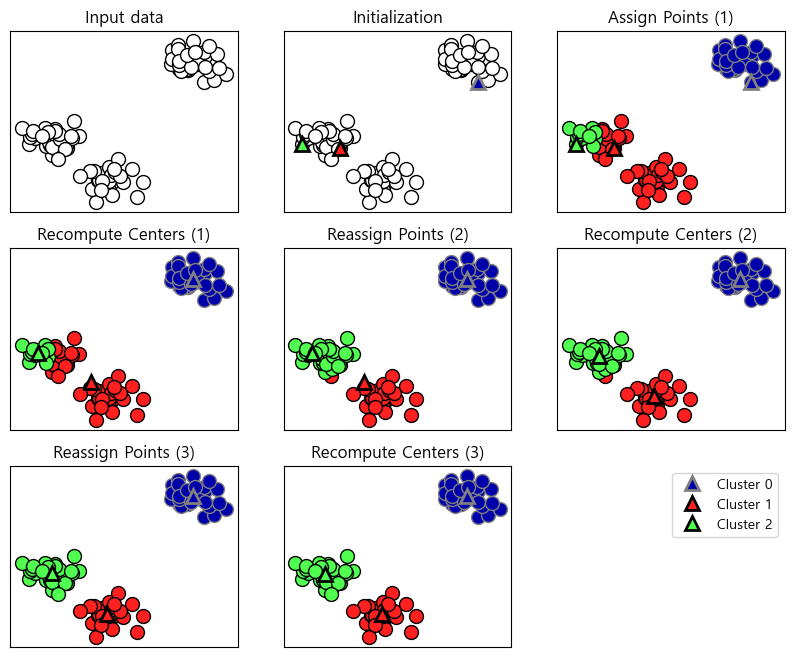

In [2]:
mglearn.plots.plot_kmeans_algorithm()

In [3]:
df = pd.read_csv('../data/kmean.csv', index_col='Unnamed: 0')
df

,x,y
0,2,3
1,2,11
2,2,18
3,4,5
4,4,7
5,5,3
6,5,15
7,6,6
8,6,8
9,6,9


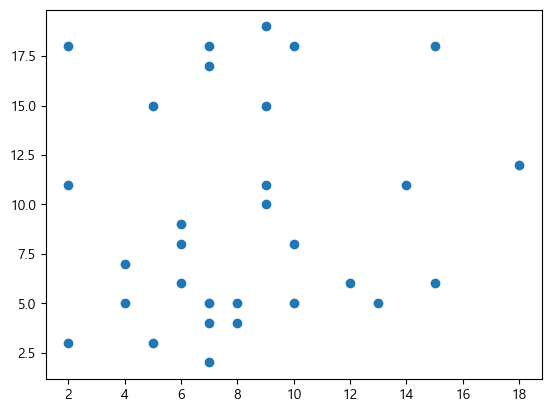

In [4]:
plt.scatter(df['x'], df['y'])
plt.show()

In [5]:
df.values

array([[ 2,  3],
       [ 2, 11],
       [ 2, 18],
       [ 4,  5],
       [ 4,  7],
       [ 5,  3],
       [ 5, 15],
       [ 6,  6],
       [ 6,  8],
       [ 6,  9],
       [ 7,  2],
       [ 7,  4],
       [ 7,  5],
       [ 7, 17],
       [ 7, 18],
       [ 8,  5],
       [ 8,  4],
       [ 9, 10],
       [ 9, 11],
       [ 9, 15],
       [ 9, 19],
       [10,  5],
       [10,  8],
       [10, 18],
       [12,  6],
       [13,  5],
       [14, 11],
       [15,  6],
       [15, 18],
       [18, 12]], dtype=int64)

In [6]:
k = KMeans(n_clusters=4)
km = k.fit(df.values)

In [7]:
km.cluster_centers_

array([[11.14285714,  7.28571429],
       [ 7.        , 17.14285714],
       [15.66666667, 13.66666667],
       [ 5.53846154,  5.53846154]])

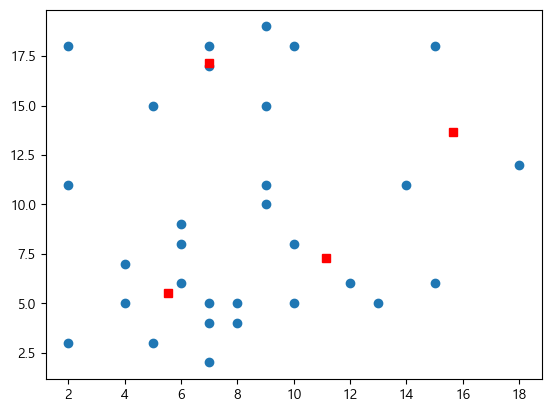

In [8]:
plt.scatter(df['x'], df['y'])
for x,y in km.cluster_centers_:
    plt.plot(x, y, 'rs')
plt.show()

In [9]:
km.labels_

array([3, 3, 1, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 1, 1, 3, 3, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 2, 0, 2, 2])

In [10]:
df['cluster'] = km.labels_

In [11]:
df

,x,y,cluster
0,2,3,3
1,2,11,3
2,2,18,1
3,4,5,3
4,4,7,3
5,5,3,3
6,5,15,1
7,6,6,3
8,6,8,3
9,6,9,3


In [12]:
import seaborn as sb

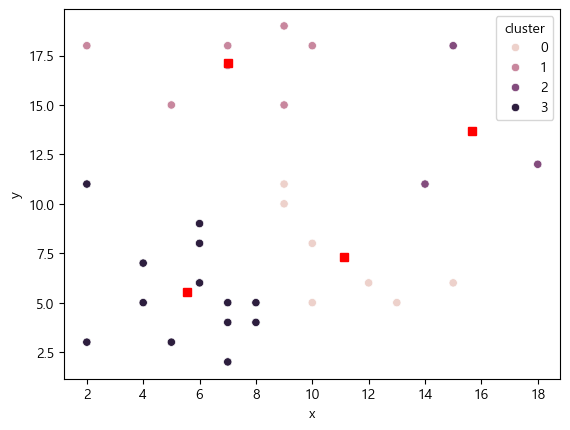

In [13]:
# sb.pairplot(df, hue='cluster')
sb.scatterplot(df, x='x', y='y', hue='cluster')
for x,y in km.cluster_centers_:
    plt.plot(x, y, 'rs')
plt.show()

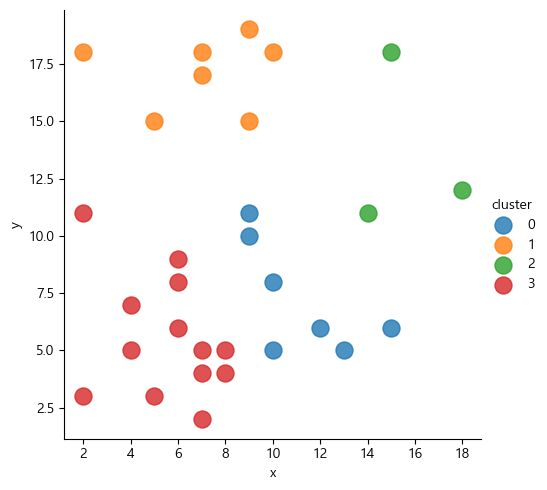

In [14]:
sb.lmplot(data=df, x='x', y='y', hue='cluster', fit_reg=False,
            scatter_kws={'s':150}) #fit_reg=False 회귀선 만들지 않도록 지정
plt.show()

In [15]:
km.inertia_ 

294.93772893772893

### 각 센터를 중심으로 떨어진 거리의 총합의 평균 : inertia_ 

In [16]:
df.drop(columns=['cluster'], inplace=True)

In [17]:
df

,x,y
0,2,3
1,2,11
2,2,18
3,4,5
4,4,7
5,5,3
6,5,15
7,6,6
8,6,8
9,6,9


In [18]:
mylist = []
for n in range(1,10):
    model = KMeans(n_clusters=n)
    km = model.fit(df)
    mylist.append(km.inertia_)

In [19]:
mylist # inertia_ 값

[1324.2666666666664,
 668.5079365079366,
 452.77777777777777,
 342.73333333333335,
 221.69047619047623,
 214.6190476190476,
 161.27380952380955,
 126.53571428571429,
 100.13095238095238]

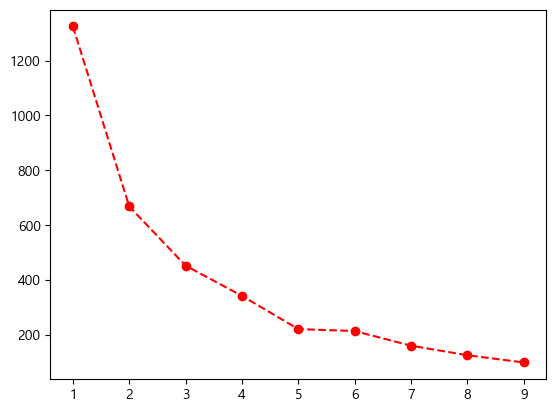

In [20]:
plt.plot( range(1,10), mylist, 'ro--') # 3 또는 4가 가장 좋음-> 급격하게 떨어지는 구간이기 때문
plt.show()